In [1]:
# importación de librerías 
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definición de rutas de las carpetas de imagenes de entrada y salida
imagenes_originales = Path("./Originales")
imagenes_procesadas = Path("./Procesadas")

# Creación de la carpeta de salida si aún no existe
imagenes_originales.mkdir(exist_ok=True)
imagenes_procesadas.mkdir(exist_ok=True)

print(f"Carpeta esperada para originales: {imagenes_originales.resolve()}")
print(f"Carpeta esperada para resultados: {imagenes_procesadas.resolve()}")

Carpeta esperada para originales: C:\Users\Tamara\Desktop\PDI 2026\pena-tamara-pdi-1c-2026\006_fotografia_digital\Originales
Carpeta esperada para resultados: C:\Users\Tamara\Desktop\PDI 2026\pena-tamara-pdi-1c-2026\006_fotografia_digital\Procesadas


In [3]:
# Funciones de apoyo
def cargar_rgb(ruta):
    imagen_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)

    if imagen_bgr is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")
    
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    return imagen_rgb


def cargar_gris(ruta):
    imagen_gris = cv2.imread(str(ruta), cv2.IMREAD_GRAYSCALE)

    if imagen_gris is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")
    
    return imagen_gris


def mostrar_imagen(imagen, titulo="Imagen"):
    plt.figure(figsize=(7, 6), constrained_layout=True)

    cmap = None
    if imagen.ndim == 2:
        cmap = "gray"

    plt.imshow(imagen, cmap=cmap)
    plt.title(titulo, fontweight="bold", loc="left")
    plt.axis("off")
    plt.show()


def mostrar_comparacion(imagen_izquierda, imagen_derecha, titulo_izquierda, titulo_derecha):
    figura, ejes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    cmap_izquierda = None
    if imagen_izquierda.ndim == 2:
        cmap_izquierda = "gray"

    cmap_derecha = None
    if imagen_derecha.ndim == 2:
        cmap_derecha = "gray"

    ejes[0].imshow(imagen_izquierda, cmap=cmap_izquierda)
    ejes[0].set_title(titulo_izquierda, fontweight="bold", loc="left")
    ejes[0].axis("off")

    ejes[1].imshow(imagen_derecha, cmap=cmap_derecha)
    ejes[1].set_title(titulo_derecha, fontweight="bold", loc="left")
    ejes[1].axis("off")

    plt.show()


def mostrar_histograma_gris(imagen):
    if imagen.ndim == 3:
        imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)
    else:
        imagen_gris = imagen

    histograma, bordes = np.histogram(imagen_gris.flatten(), bins=256, range=[0, 256])

    plt.figure(figsize=(10, 4), constrained_layout=True)
    plt.plot(bordes[:-1], histograma, color="black")
    plt.title("Histograma en escala de grises", fontweight="bold", loc="left")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de pixeles")
    plt.xlim(0, 255)
    plt.grid(alpha=0.3)
    plt.show()


def mostrar_canales_rgb(imagen_rgb):
    canal_rojo = imagen_rgb[:, :, 0]
    canal_verde = imagen_rgb[:, :, 1]
    canal_azul = imagen_rgb[:, :, 2]

    figura, ejes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

    ejes[0, 0].imshow(imagen_rgb)
    ejes[0, 0].set_title("Imagen original", fontweight="bold", loc="left")
    ejes[0, 0].axis("off")

    ejes[0, 1].imshow(canal_rojo, cmap="gray")
    ejes[0, 1].set_title("Canal rojo", fontweight="bold", loc="left")
    ejes[0, 1].axis("off")

    ejes[1, 0].imshow(canal_verde, cmap="gray")
    ejes[1, 0].set_title("Canal verde", fontweight="bold", loc="left")
    ejes[1, 0].axis("off")

    ejes[1, 1].imshow(canal_azul, cmap="gray")
    ejes[1, 1].set_title("Canal azul", fontweight="bold", loc="left")
    ejes[1, 1].axis("off")

    plt.show()


def guardar_rgb(ruta_salida, imagen_rgb):
    imagen_bgr = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(ruta_salida), imagen_bgr)


def guardar_gris(ruta_salida, imagen_gris):
    cv2.imwrite(str(ruta_salida), imagen_gris)

PARTE 1

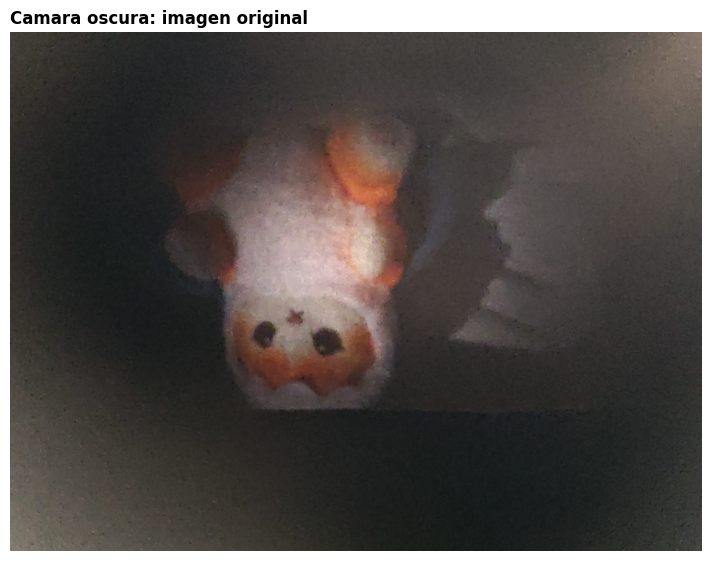

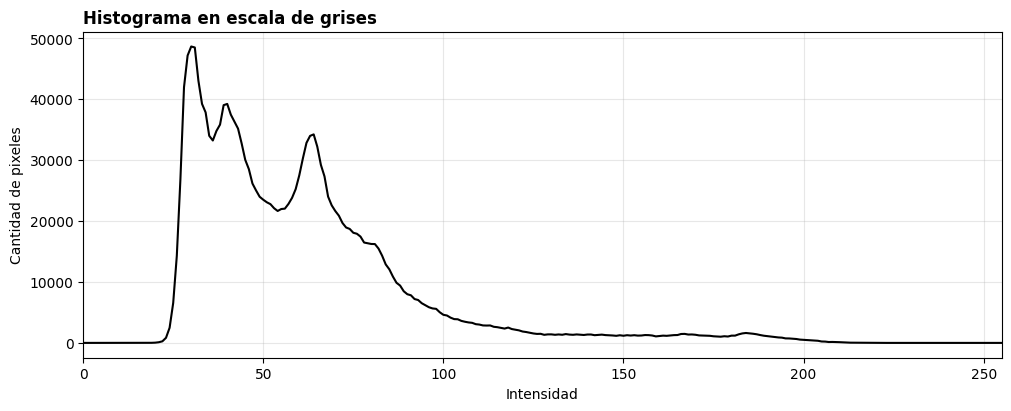

In [ ]:
nombre_imagen_camara_oscura = "camara_oscura_imagen.jpeg"

imagen_camara_oscura_rgb = None

if nombre_imagen_camara_oscura != "":
    ruta_camara_oscura = imagenes_originales / nombre_imagen_camara_oscura
    imagen_camara_oscura_rgb = cargar_rgb(ruta_camara_oscura)

    mostrar_imagen(imagen_camara_oscura_rgb, "Camara oscura: imagen original")
    mostrar_histograma_gris(imagen_camara_oscura_rgb)


Tamaño original: 1600 x 1200


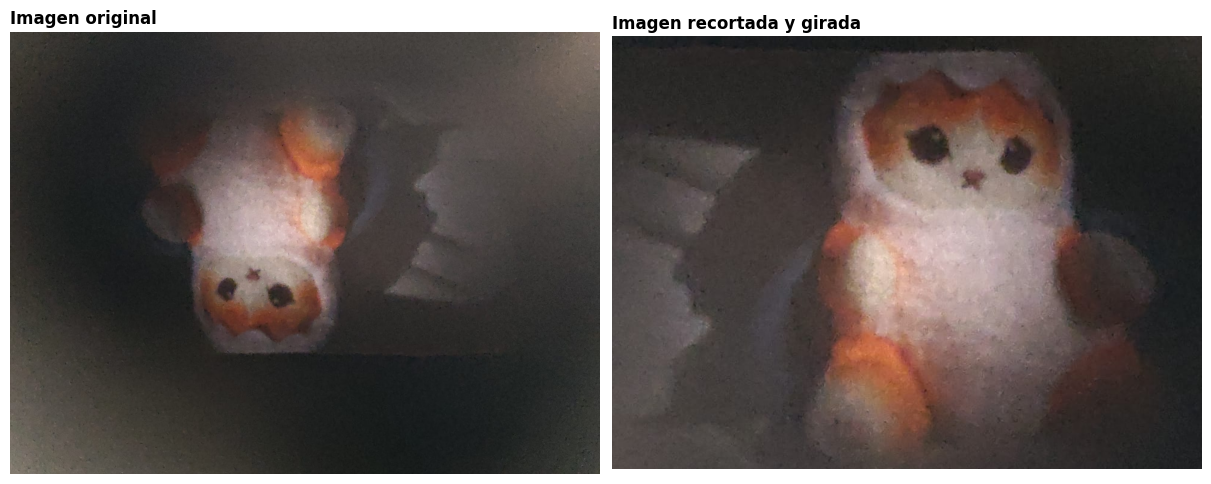

In [16]:
# Recortamos y giramos la imagen
imagen_trabajo = imagen_camara_oscura_rgb.copy()

alto, ancho = imagen_trabajo.shape[:2]
print("Tamaño original:", ancho, "x", alto)

x1 = 280
x2 = 1260
y1 = 180
y2 = 900

imagen_recortada = imagen_trabajo[y1:y2, x1:x2]

corregir_orientacion = True

if corregir_orientacion:
    imagen_recortada = cv2.rotate(imagen_recortada, cv2.ROTATE_180)

imagen_camara_oscura_corregida = imagen_recortada

mostrar_comparacion(
    imagen_camara_oscura_rgb,
    imagen_camara_oscura_corregida,
    "Imagen original",
    "Imagen recortada y girada"
)


In [ ]:
imagen_base_hsv = imagen_camara_oscura_corregida.copy()
# Convertis a HSV


imagen_hsv = cv2.cvtColor(
    imagen_base_hsv,
    cv2.COLOR_RGB2HSV
)

print("Imagen RGB:", imagen_base_hsv.shape)
print("Imagen HSV:", imagen_hsv.shape)

Imagen RGB: (720, 980, 3)
Imagen HSV: (720, 980, 3)


In [18]:
# Separacion de canales
canal_h, canal_s, canal_v = cv2.split(imagen_hsv)

print("Canal H:", canal_h.shape, canal_h.min(), canal_h.max())
print("Canal S:", canal_s.shape, canal_s.min(), canal_s.max())
print("Canal V:", canal_v.shape, canal_v.min(), canal_v.max())

Canal H: (720, 980) 0 179
Canal S: (720, 980) 0 200
Canal V: (720, 980) 17 251


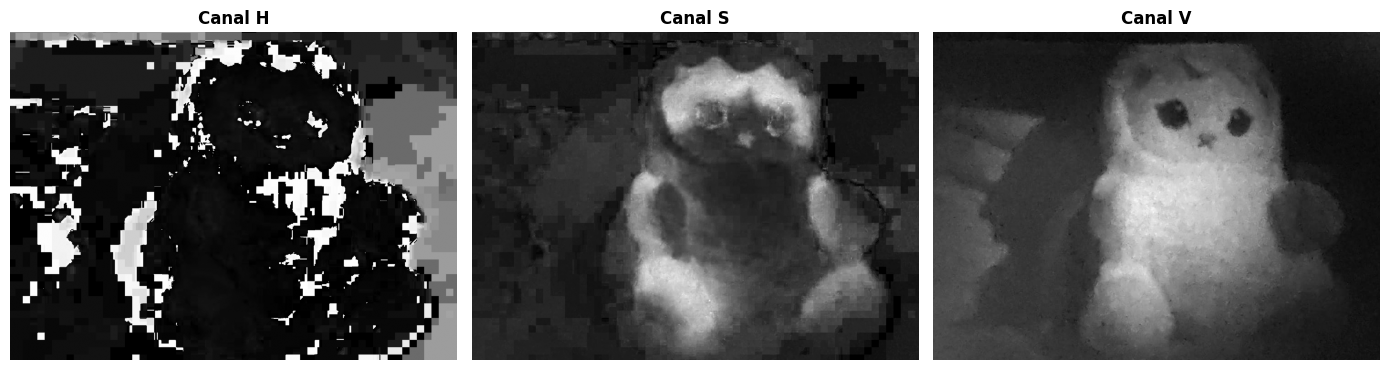

In [19]:
# Visualizamos los canales

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.imshow(canal_h, cmap="gray")
plt.title("Canal H", fontweight="bold")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(canal_s, cmap="gray")
plt.title("Canal S", fontweight="bold")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(canal_v, cmap="gray")
plt.title("Canal V", fontweight="bold")
plt.axis("off")

plt.tight_layout()
plt.show()

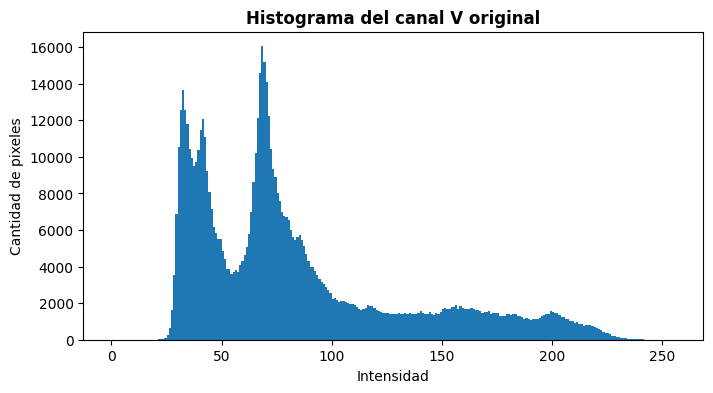

In [20]:
# Histograma del canal V

plt.figure(figsize=(8, 4))

plt.hist(
    canal_v.ravel(),
    bins=256,
    range=(0, 256)
)

plt.title("Histograma del canal V original", fontweight="bold")
plt.xlabel("Intensidad")
plt.ylabel("Cantidad de pixeles")

plt.show()

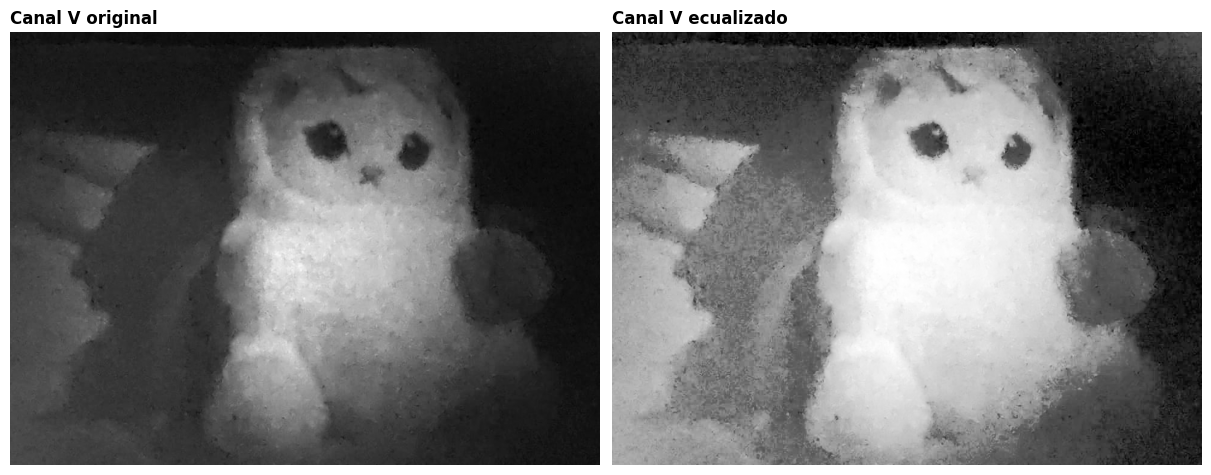

In [21]:
# Ecualizacion canal V

canal_v_ecualizado = cv2.equalizeHist(canal_v)

mostrar_comparacion(
    canal_v,
    canal_v_ecualizado,
    "Canal V original",
    "Canal V ecualizado"
)

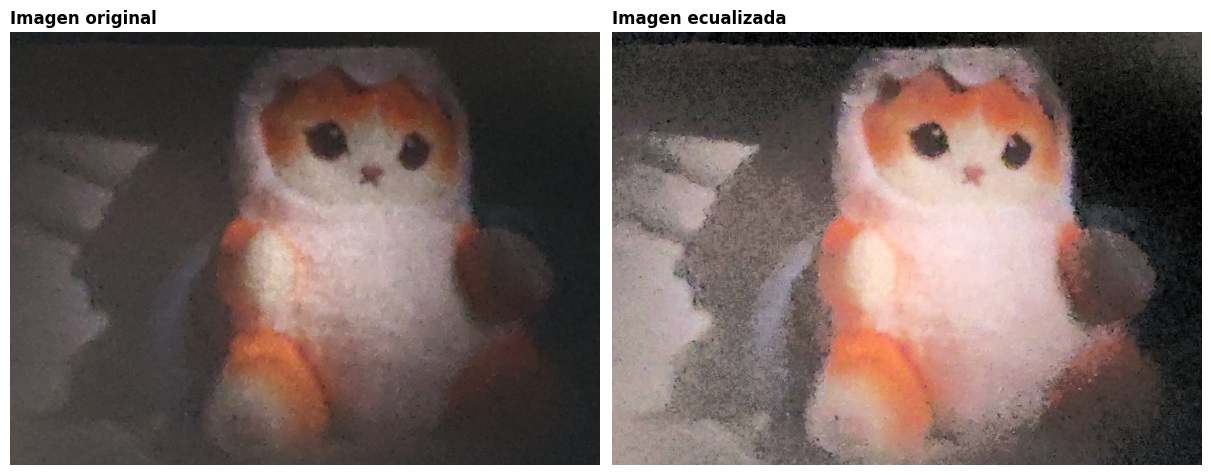

In [22]:
# Reconstruccion de la imagen
imagen_hsv_ecualizada = cv2.merge([
    canal_h,
    canal_s,
    canal_v_ecualizado
])

imagen_ecualizada_rgb = cv2.cvtColor(
    imagen_hsv_ecualizada,
    cv2.COLOR_HSV2RGB
)

mostrar_comparacion(
    imagen_base_hsv,
    imagen_ecualizada_rgb,
    "Imagen original",
    "Imagen ecualizada"
)

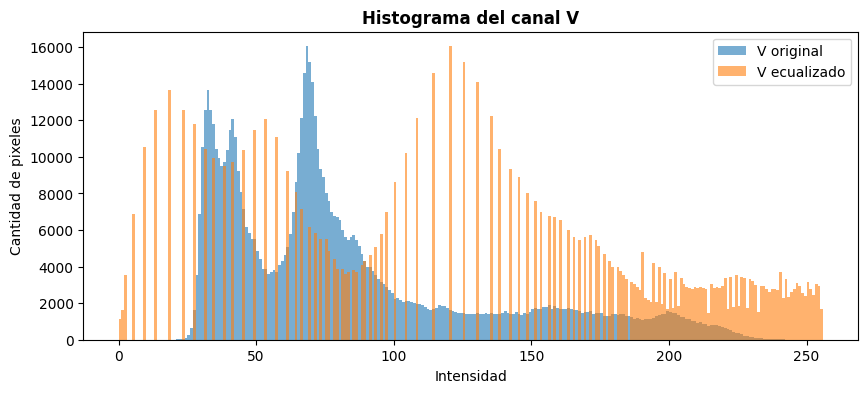

In [23]:
# Histograma del antes/despues

plt.figure(figsize=(10, 4))

plt.hist(
    canal_v.ravel(),
    bins=256,
    range=(0, 256),
    alpha=0.6,
    label="V original"
)

plt.hist(
    canal_v_ecualizado.ravel(),
    bins=256,
    range=(0, 256),
    alpha=0.6,
    label="V ecualizado"
)

plt.title("Histograma del canal V", fontweight="bold")
plt.xlabel("Intensidad")
plt.ylabel("Cantidad de pixeles")

plt.legend()
plt.show()

In [35]:
ruta_hsv_final = imagenes_procesadas / "camara_oscura_hsv_ecualizada.png"

guardar_rgb(
    ruta_hsv_final,
    imagen_ecualizada_rgb
)

print("Imagen HSV guardada en:", ruta_hsv_final)

Imagen HSV guardada en: Procesadas\camara_oscura_hsv_ecualizada.png


PARTE 2 - ACTIVIDAD 4

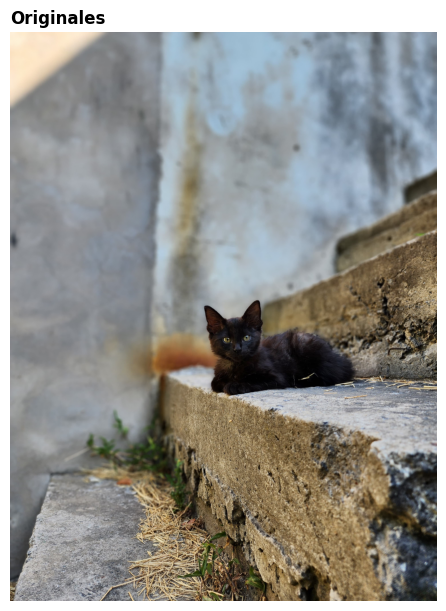

In [43]:
nombre_imagen_simplicidad = "imagen_sujeto_principal.jpeg"

ruta_simplicidad = imagenes_originales / nombre_imagen_simplicidad
imagen_simplicidad_rgb = cargar_rgb(ruta_simplicidad)

mostrar_imagen(imagen_simplicidad_rgb, "Originales")

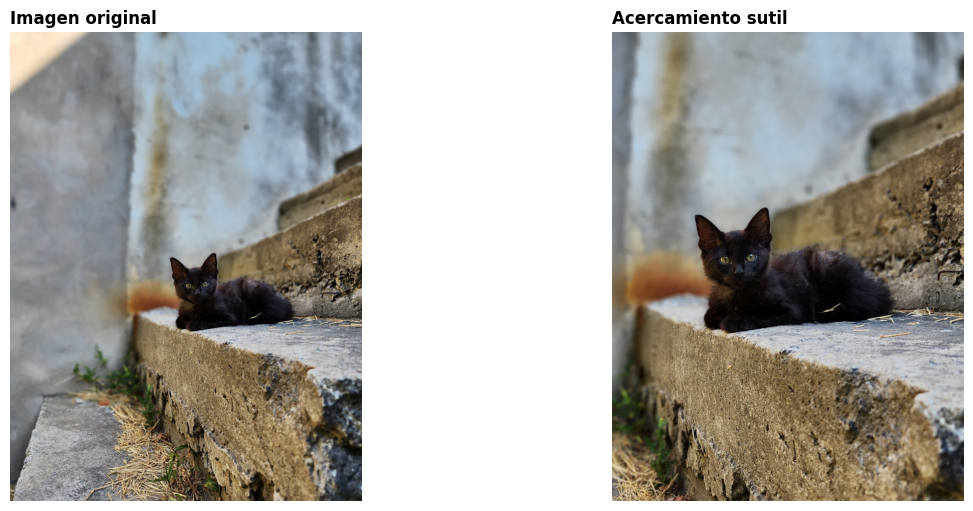

In [55]:
# Acercamiento a objeto
alto, ancho = imagen_simplicidad_rgb.shape[:2]

zoom = 1.60

nuevo_ancho = int(ancho / zoom)
nuevo_alto = int(alto / zoom)

centro_x = int(ancho * 0.62)
centro_y = int(alto * 0.55)

x1 = centro_x - nuevo_ancho // 2
x2 = centro_x + nuevo_ancho // 2
y1 = centro_y - nuevo_alto // 2
y2 = centro_y + nuevo_alto // 2

imagen_simplicidad_zoom = imagen_simplicidad_rgb[y1:y2, x1:x2]

imagen_simplicidad_zoom = cv2.resize(
    imagen_simplicidad_zoom,
    (ancho, alto)
)

mostrar_comparacion(
    imagen_simplicidad_rgb,
    imagen_simplicidad_zoom,
    "Imagen original",
    "Acercamiento sutil"
)

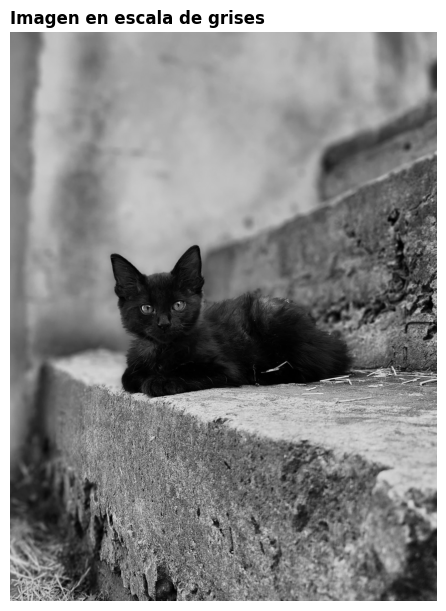

In [56]:
# Convertir a escala de grises
imagen_simplicidad_gris = cv2.cvtColor(
    imagen_simplicidad_zoom,
    cv2.COLOR_RGB2GRAY
)

mostrar_imagen(imagen_simplicidad_gris, "Imagen en escala de grises")

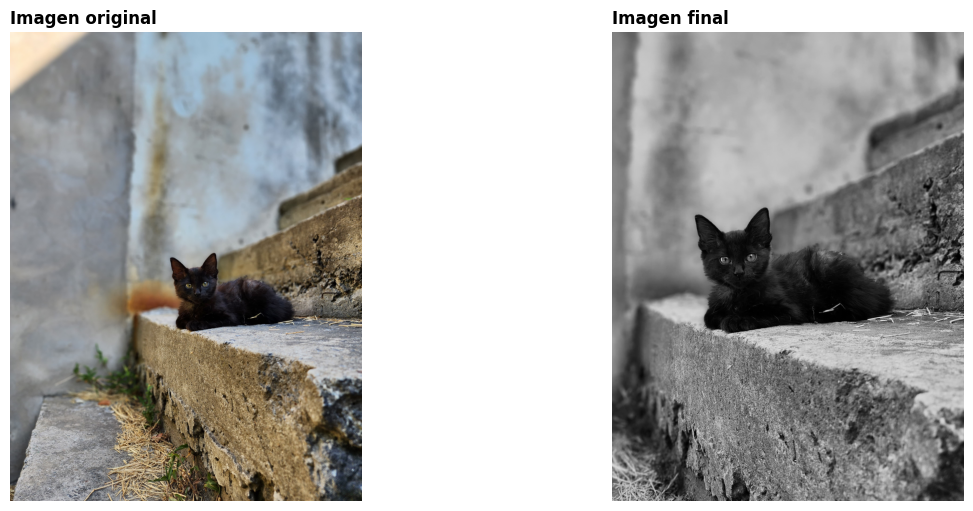

In [57]:
# Comparación original - final
mostrar_comparacion(
    imagen_simplicidad_rgb,
    imagen_simplicidad_gris,
    "Imagen original",
    "Imagen final"
)

In [58]:
# Guardar imagen final
ruta_simplicidad_final = imagenes_procesadas / "simplicidad_visual_grises.png"

guardar_gris(
    ruta_simplicidad_final,
    imagen_simplicidad_gris
)

print("Imagen guardada en:", ruta_simplicidad_final)

Imagen guardada en: Procesadas\simplicidad_visual_grises.png


Actividad 5

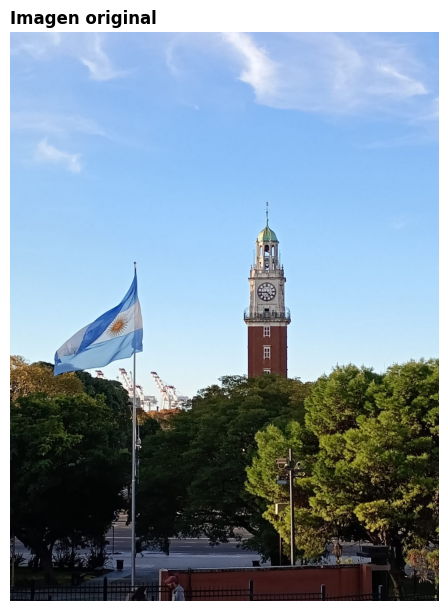

Tamaño: (1600, 1204, 3)


In [61]:
nombre_imagen_reencuadre = "imagen_reencuadre.jpeg"

ruta_reencuadre = imagenes_originales / nombre_imagen_reencuadre
imagen_reencuadre_rgb = cargar_rgb(ruta_reencuadre)

mostrar_imagen(imagen_reencuadre_rgb, "Imagen original")
print("Tamaño:", imagen_reencuadre_rgb.shape)

In [66]:
# Definicion de recortes

# Recorte A: bandera con mastil
x1_a = 70
x2_a = 460 
y1_a = 620
y2_a = 1480

# Recorte B: torre del reloj con más cielo y parte inferior
x1_b = 570
x2_b = 910
y1_b = 410
y2_b = 1150

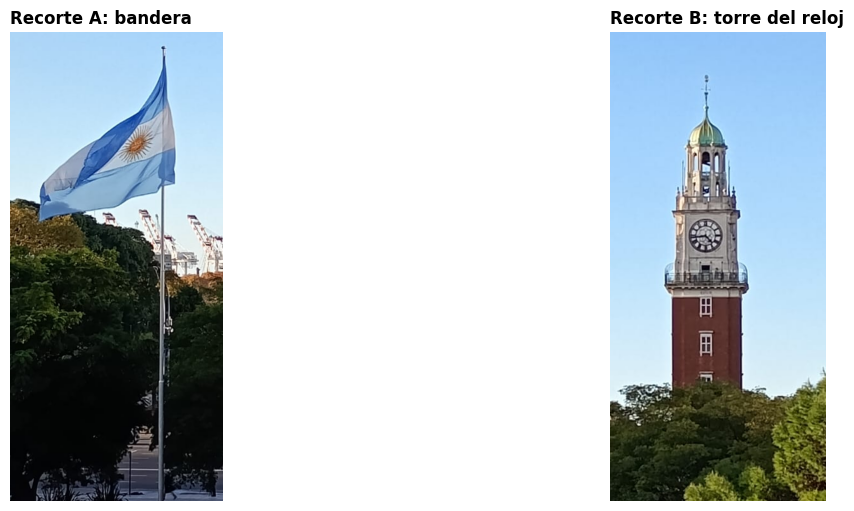

In [67]:
# Generación de recortes
recorte_a = imagen_reencuadre_rgb[y1_a:y2_a, x1_a:x2_a]
recorte_b = imagen_reencuadre_rgb[y1_b:y2_b, x1_b:x2_b]

mostrar_comparacion(
    recorte_a,
    recorte_b,
    "Recorte A: bandera",
    "Recorte B: torre del reloj"
)

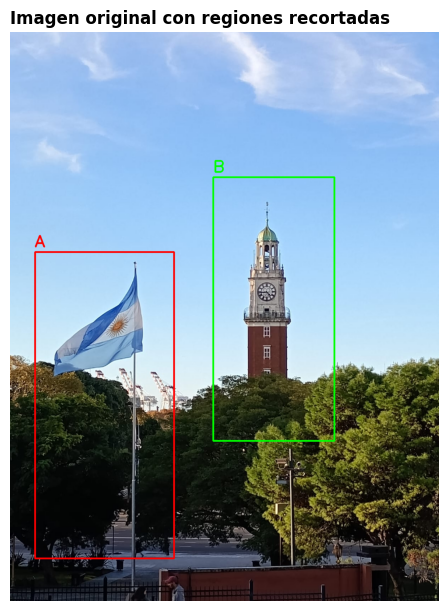

In [68]:
# Marcar regiones recortadas sobre original
imagen_con_marcas = imagen_reencuadre_rgb.copy()

cv2.rectangle(
    imagen_con_marcas,
    (x1_a, y1_a),
    (x2_a, y2_a),
    (255, 0, 0),
    4
)

cv2.rectangle(
    imagen_con_marcas,
    (x1_b, y1_b),
    (x2_b, y2_b),
    (0, 255, 0),
    4
)

cv2.putText(
    imagen_con_marcas,
    "A",
    (x1_a, y1_a - 15),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.5,
    (255, 0, 0),
    4
)

cv2.putText(
    imagen_con_marcas,
    "B",
    (x1_b, y1_b - 15),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.5,
    (0, 255, 0),
    4
)

mostrar_imagen(imagen_con_marcas, "Imagen original con regiones recortadas")

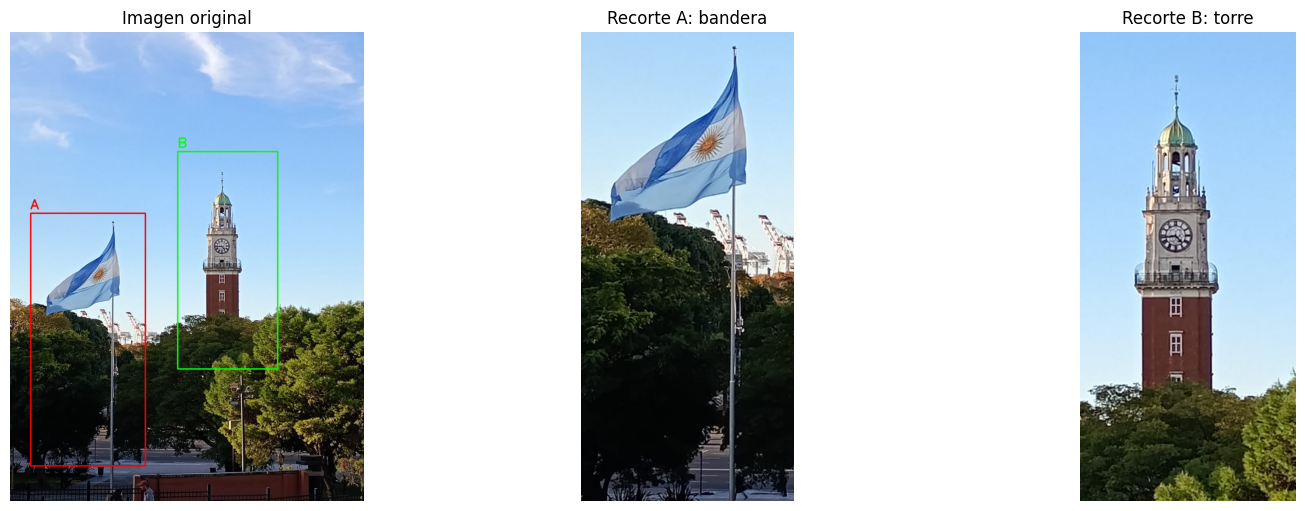

In [69]:
# Mostrar original marcada + recortes
figura, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

ejes[0].imshow(imagen_con_marcas)
ejes[0].set_title("Imagen original")
ejes[0].axis("off")

ejes[1].imshow(recorte_a)
ejes[1].set_title("Recorte A: bandera")
ejes[1].axis("off")

ejes[2].imshow(recorte_b)
ejes[2].set_title("Recorte B: torre")
ejes[2].axis("off")

plt.show()

In [ ]:
# Guardar resultados
ruta_reencuadre_marcas = imagenes_procesadas / "reencuadre_original_con_marcas.png"
ruta_recorte_a = imagenes_procesadas / "reencuadre_a_bandera.png"
ruta_recorte_b = imagenes_procesadas / "reencuadre_b_torre.png"

guardar_rgb(ruta_reencuadre_marcas, imagen_con_marcas)
guardar_rgb(ruta_recorte_a, recorte_a)
guardar_rgb(ruta_recorte_b, recorte_b)

print("Imagen con marcas guardada en:", ruta_reencuadre_marcas)
print("Recorte A guardado en:", ruta_recorte_a)
print("Recorte B guardado en:", ruta_recorte_b)

Imagen con marcas guardada en: Procesadas\reencuadre_original_con_marcas.png
Recorte A guardado en: Procesadas\reencuadre_a_bandera.png
Recorte B guardado en: Procesadas\reencuadre_b_torre.png


: 